# Week 7 — Supervised Classification

This notebook covers the third project milestone:
- Load the 194-feature matrix extracted in notebook 02
- Split into train / test sets and scale features using **MiniLearn**
- Train four classifiers: KNN, Logistic Regression, Gaussian Naive Bayes, Decision Tree
- Evaluate each with accuracy, macro-averaged F1, and a full classification report
- Visualise per-class confusion matrices
- Produce a side-by-side summary table for comparison

In [1]:
import sys
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make minilearn importable from the notebooks directory
sys.path.insert(0, os.path.abspath('..'))

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import KNN, LogisticRegression, GaussianNaiveBayes, DecisionTreeClassifier
from minilearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load Feature Matrix

In [2]:
df = pd.read_csv('../outputs/features.csv')

LABEL_COLS = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X = df[feature_cols].values          # (2452, 194)  float64
y = df['emotion'].values             # (2452,)       string labels

EMOTION_ORDER = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

print(f'Feature matrix : {X.shape}')
print(f'Classes        : {np.unique(y).tolist()}')
print(f'Class counts   :')
for em in EMOTION_ORDER:
    print(f'  {em:10s}: {np.sum(y == em)}')

Feature matrix : (2452, 194)
Classes        : ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Class counts   :
  neutral   : 188
  calm      : 376
  happy     : 376
  sad       : 376
  angry     : 376
  fearful   : 376
  disgust   : 192
  surprised : 192


## 2. Train / Test Split and Feature Scaling

We hold out 20 % of samples as a test set.  The `StandardScaler` is **fit only on the
training set** and then applied to both splits — this prevents data leakage.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train samples : {len(X_train)}')
print(f'Test samples  : {len(X_test)}')
print(f'Feature mean after scaling (train): {X_train_s.mean():.4f}  (should be ~0)')
print(f'Feature std  after scaling (train): {X_train_s.std():.4f}  (should be ~1)')

Train samples : 1961
Test samples  : 491
Feature mean after scaling (train): 0.0000  (should be ~0)
Feature std  after scaling (train): 1.0000  (should be ~1)


## 3. Train and Evaluate Classifiers

Each classifier is wrapped in a helper that records training time, test accuracy, and
macro-F1.  We then inspect each one individually.

In [4]:
classifiers = [
    ('KNN (k=5)',           KNN(n_neighbors=5)),
    ('Logistic Regression', LogisticRegression(lr=0.1, max_iter=500, random_state=RANDOM_STATE)),
    ('Gaussian Naive Bayes',GaussianNaiveBayes()),
    ('Decision Tree (d=10)',DecisionTreeClassifier(max_depth=10)),
]

results = {}   # name -> {'clf', 'y_pred', 'acc', 'f1', 'train_time'}

for name, clf in classifiers:
    t0 = time.time()
    clf.fit(X_train_s, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_test_s)
    pred_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')

    results[name] = dict(clf=clf, y_pred=y_pred, acc=acc, f1=f1, train_time=train_time)
    print(f'{name:25s}  acc={acc:.3f}  macro-F1={f1:.3f}  '
          f'train={train_time:.1f}s  predict={pred_time:.1f}s')

KNN (k=5)                  acc=0.662  macro-F1=0.651  train=0.0s  predict=0.4s


Logistic Regression        acc=0.731  macro-F1=0.730  train=0.8s  predict=0.0s
Gaussian Naive Bayes       acc=0.430  macro-F1=0.421  train=0.0s  predict=0.0s


Decision Tree (d=10)       acc=0.493  macro-F1=0.472  train=47.0s  predict=0.0s


## 4. Per-Classifier Classification Reports

In [5]:
for name, res in results.items():
    print(f'\n{"=" * 55}')
    print(f'  {name}')
    print(f'{"=" * 55}')
    print(classification_report(
        y_test, res['y_pred'],
        labels=EMOTION_ORDER,
        target_names=EMOTION_ORDER
    ))


  KNN (k=5)
                 precision     recall   f1-score    support

        neutral       0.74       0.76       0.75         38
           calm       0.73       0.75       0.74         88
          happy       0.55       0.52       0.53         67
            sad       0.74       0.59       0.65         70
          angry       0.61       0.67       0.64         67
        fearful       0.61       0.61       0.61         82
        disgust       0.66       0.56       0.60         44
      surprised       0.57       0.86       0.68         35

       accuracy                             0.66        491
      macro avg       0.65       0.66       0.65        491

  Logistic Regression
                 precision     recall   f1-score    support

        neutral       0.80       0.84       0.82         38
           calm       0.82       0.84       0.83         88
          happy       0.83       0.66       0.73         67
            sad       0.71       0.68       0.70         70
 

## 5. Confusion Matrices

Each cell (i, j) shows how many true-class-i samples were predicted as class j.
A perfect classifier has all mass on the diagonal.

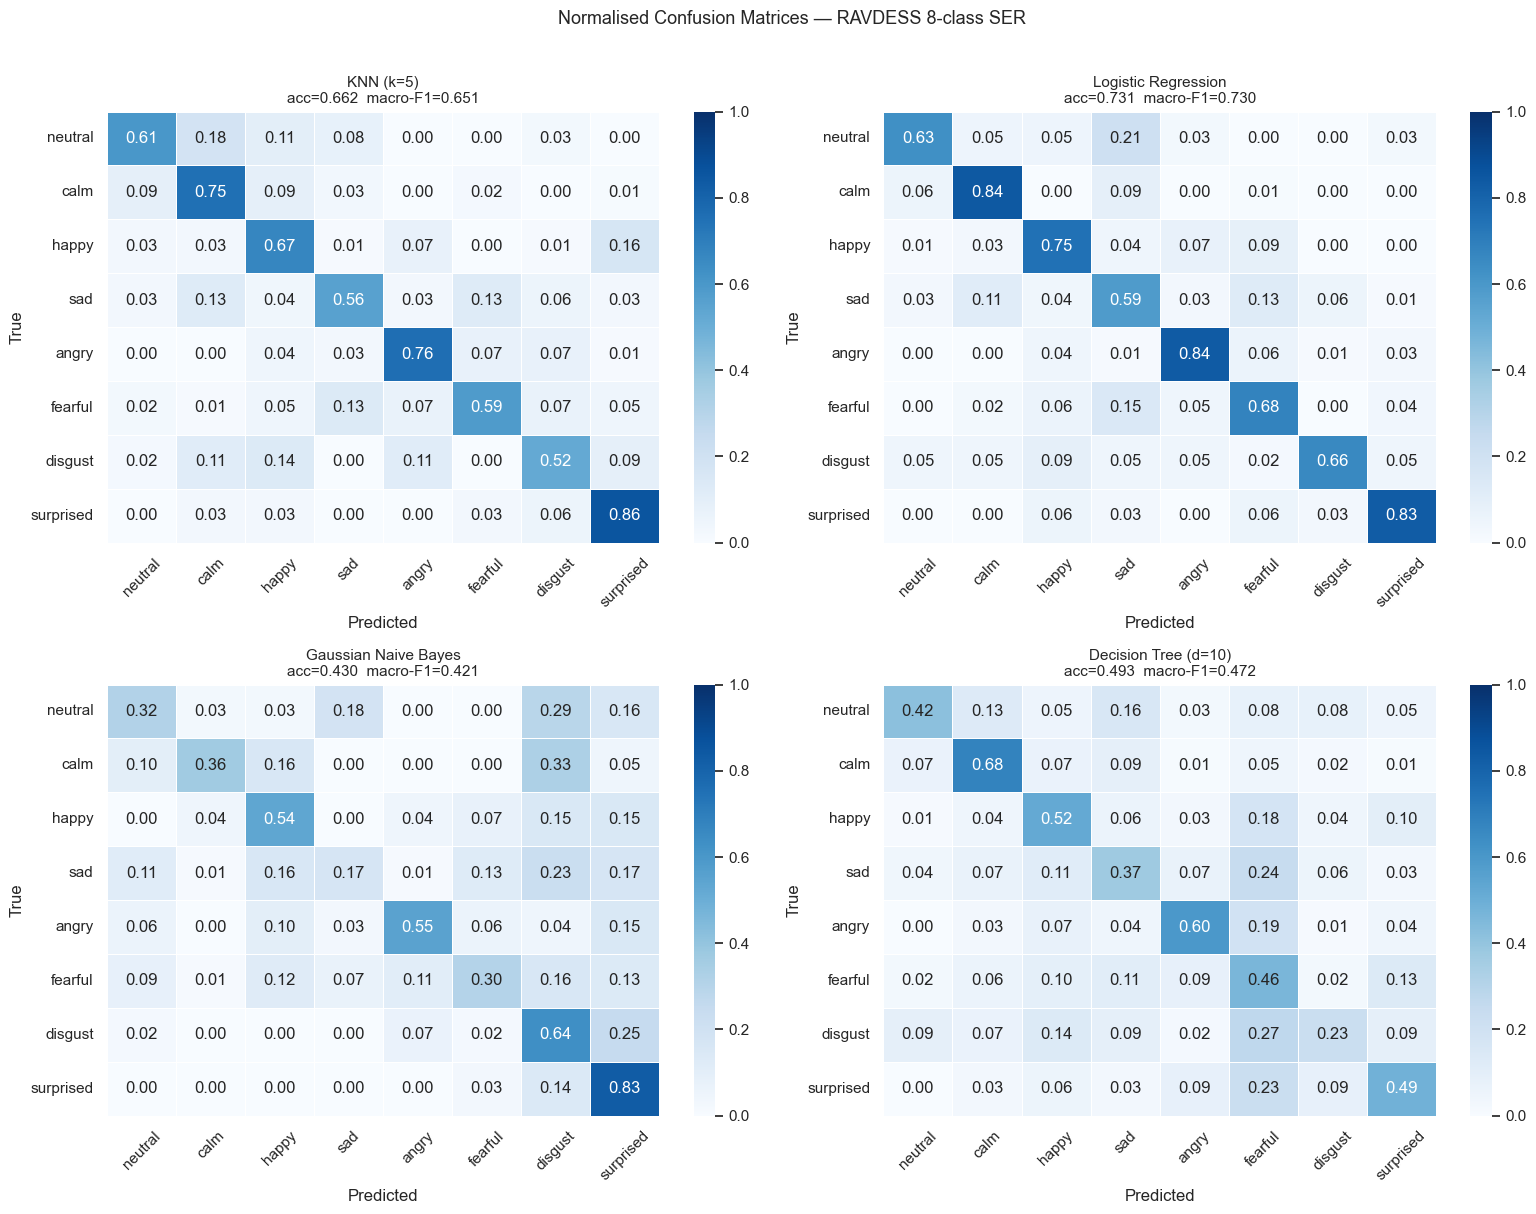

Saved to outputs/confusion_matrices.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=EMOTION_ORDER)
    # normalise rows to show recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER,
        ax=ax, vmin=0, vmax=1, linewidths=0.4
    )
    ax.set_title(f'{name}\nacc={res["acc"]:.3f}  macro-F1={res["f1"]:.3f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Normalised Confusion Matrices — RAVDESS 8-class SER', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/confusion_matrices.png')

## 6. Summary Comparison Table

In [7]:
summary = pd.DataFrame([
    {
        'Classifier'  : name,
        'Test Accuracy': f"{res['acc']:.3f}",
        'Macro F1'    : f"{res['f1']:.3f}",
        'Train Time (s)': f"{res['train_time']:.1f}",
    }
    for name, res in results.items()
])

print(summary.to_string(index=False))
summary

          Classifier Test Accuracy Macro F1 Train Time (s)
           KNN (k=5)         0.662    0.651            0.0
 Logistic Regression         0.731    0.730            0.8
Gaussian Naive Bayes         0.430    0.421            0.0
Decision Tree (d=10)         0.493    0.472           47.0


,Classifier,Test Accuracy,Macro F1,Train Time (s)
0,KNN (k=5),0.662,0.651,0.0
1,Logistic Regression,0.731,0.730,0.8
2,Gaussian Naive Bayes,0.430,0.421,0.0
3,Decision Tree (d=10),0.493,0.472,47.0


## 7. Per-Class F1 Bar Chart

Showing how each classifier handles each emotion individually.

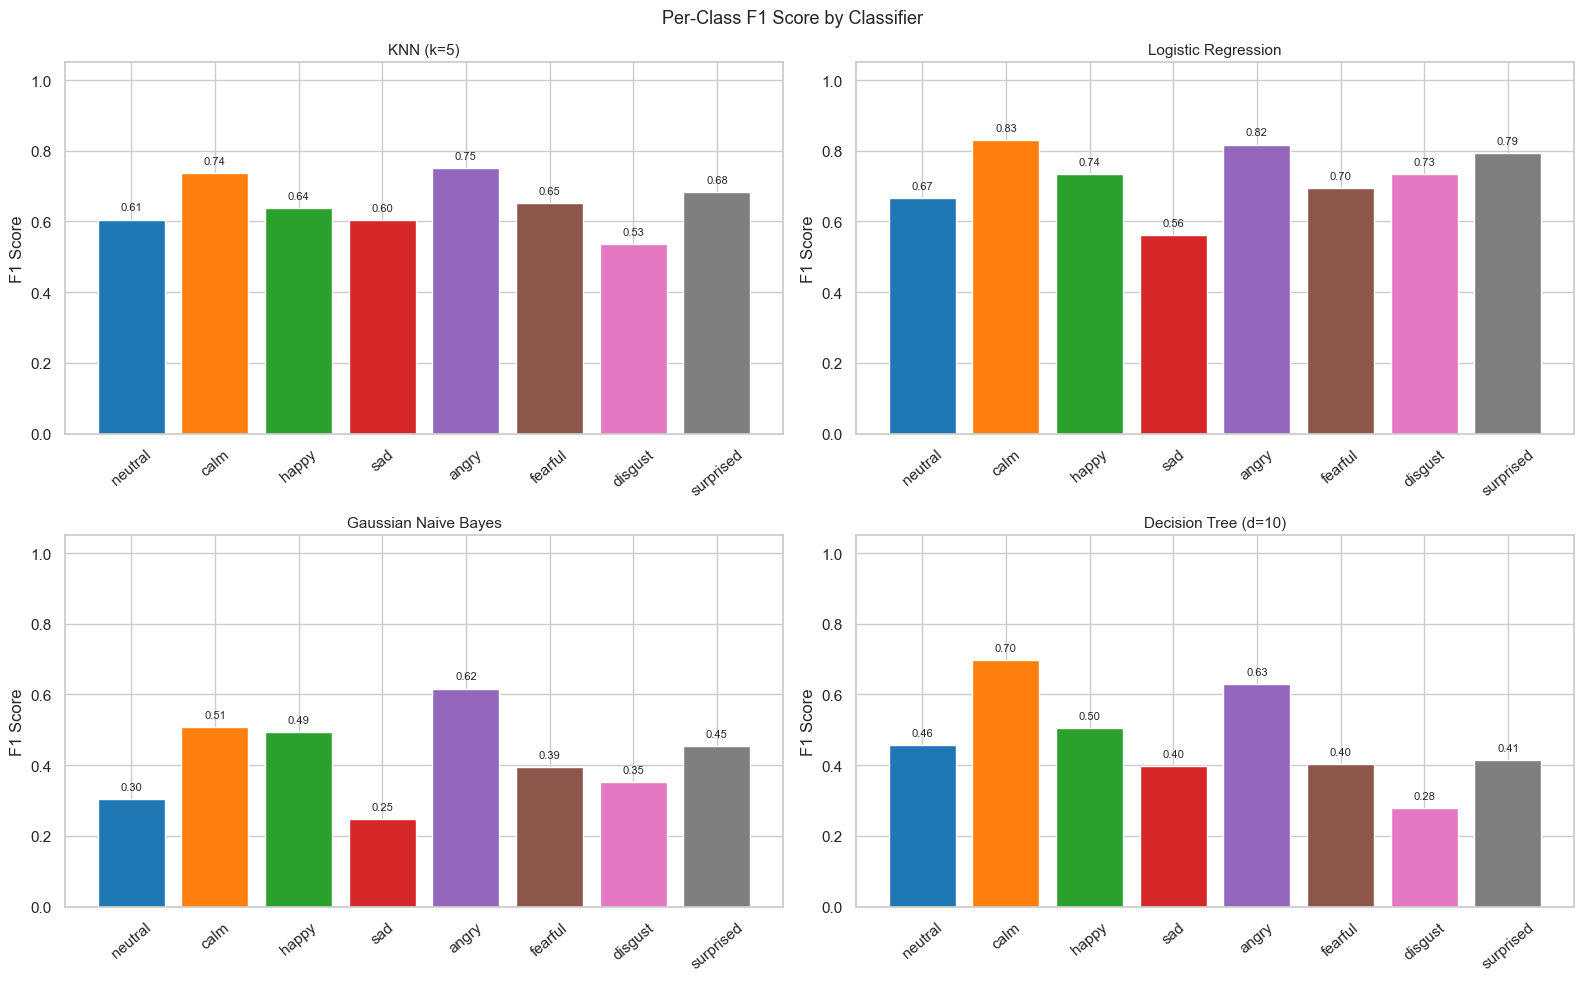

Saved to outputs/per_class_f1.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
palette = sns.color_palette('tab10', len(EMOTION_ORDER))

for ax, (name, res) in zip(axes, results.items()):
    per_class_f1 = f1_score(y_test, res['y_pred'], average=None)
    # f1_score(average=None) returns list aligned to sorted unique labels
    # reorder to EMOTION_ORDER
    unique_labels = sorted(np.unique(np.concatenate([y_test, res['y_pred']])))
    label_to_f1 = dict(zip(unique_labels, per_class_f1))
    f1_vals = [label_to_f1.get(em, 0.0) for em in EMOTION_ORDER]

    bars = ax.bar(EMOTION_ORDER, f1_vals, color=palette)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{name}', fontsize=11)
    ax.set_ylabel('F1 Score')
    ax.tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Per-Class F1 Score by Classifier', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/per_class_f1.png')